## NEURON

In [ ]:
import numpy as np
a = np.linspace(-30, 30, 7)
print(a)

array([ 4.83600262e-04,  4.83600262e-04,  2.56023668e-04,  2.84470742e-05,
        1.99129520e-04,  3.41364891e-04,  2.56023668e-05,  5.68941484e-05,
       -7.50000000e+01,  1.00000000e+00,  1.00000000e+00])
soma { nseg=1  L=10.5781  Ra=100
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10.5781}
	insert capacitance { cm=1}
}
All parameters used in current clamp:
soma { nseg=1  L=10.5781  Ra=100
	/*location 0 attached to cell 0*/
	/* First segment only */
	insert morphology { diam=10.5781}
	insert capacitance { cm=1}
	insert slo2egl19 { gbar_slo2egl19=0.0004836}
	insert slo2iso { gbar_slo2iso=0.0004836 c2_slo2iso=1}
	insert egl19 { gbar_egl19=0.000256024}
	insert cca1 { gbar_cca1=2.84471e-05}
	insert irk { gbar_irk=0.00019913}
	insert shk1 { gbar_shk1=0.000341365}
	insert k_ion { ek=-80}
	insert leak { gbar_leak=5.68941e-05 e_leak=-75}
	insert nca { gbar_nca=2.56024e-05 e_nca=30}
	insert cadiff {}
	insert ca_ion {}
	insert IClamp { del=100 dur=10

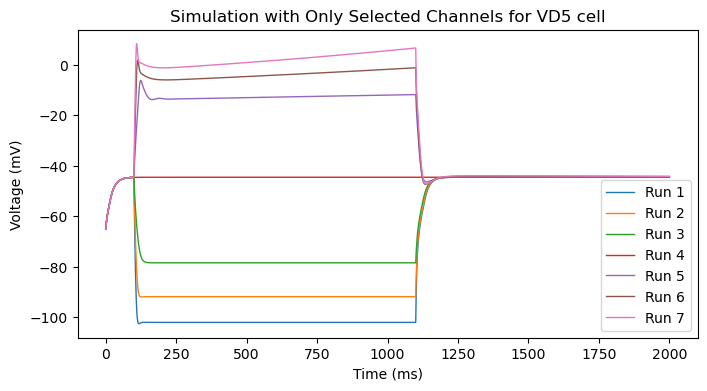

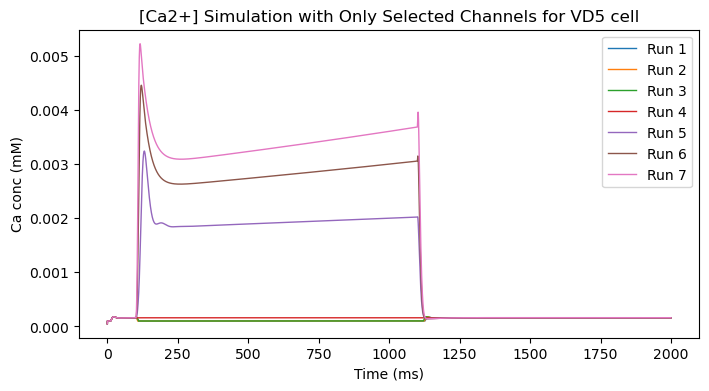

IClamp[0]


In [4]:

import sys
sys.path.append('..')  # the parent directory
from VD5_simulation_iclamp import VD5_simulation_iclamp
from g_to_Scm2 import gScm2
import pprint

surf=351.53e-8

# conductances: slo2egl19, slo2iso, egl19, cca1, irk, shk1, nca, leak 
g0=[1.7,1.7,0.9,0.1,0.7,1.2,0.09,0.2,-75,1,1]#finale 

# leak + egl19
g0=[1.7, # slo2EGL19 = 1.7 DONE
    1.7, # slo2iso = 1.7  DONE
    0.9, # egl19= 0.9    DONE
    0.1,   # cca = 0.1   DONE
    0.7, # irk  = 0.7  DONE
    1.2, # shk1 = 1.2   DONE
    0.09, # nca = 0.09   DONE
    0.2, # leak = 0.2   DONE
    -75,1,1.0] # eleak, slo2iso.c2, cm
  



    
gVD5_scaled = gScm2(g0,surf,7)
pprint.pprint(gVD5_scaled)


v, time1, ca, soma, stim = VD5_simulation_iclamp(gVD5_scaled, s1=-0.030, s2=0.030, ns=7, delay=100, duration=1000, simdur = 2000, transient=0, V_init = -45)
#s2 = 0.035
# best_cc=AIY_simulation_iclamp(gbest,-0.015,0.035,11)
# best_voltage=best_cc[0]
# best_time2=best_cc[1]
# best_VIss=best_cc[3]
# best_VIpeaks=best_cc[2]


# #Matplotlib

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
for i in range(len(v)):
    plt.plot(time1[i], v[i], label=f'Run {i + 1}', linewidth=1)
plt.title('Simulation with Only Selected Channels for VD5 cell')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.figure(figsize=(8, 4))

for i in range(len(ca)):
    plt.plot(time1[i], ca[i], label=f'Run {i + 1}', linewidth=1)
plt.title('[Ca2+] Simulation with Only Selected Channels for VD5 cell')
plt.xlabel('Time (ms)')
plt.ylabel('Ca conc (mM)')
plt.legend()

plt.show()
print(stim)

In [ ]:
stim

## NeuroML

In [2]:
import pandas as pd
from pyneuroml import pynml

def run_simulation_and_get_results(lems_file):
    # Run the simulation with pyNeuroML
    print(f"Running simulation: {lems_file}")
    results = pynml.run_lems_with_jneuroml(
        lems_file, 
        max_memory="1024M", 
        nogui=True, 
        plot=False, 
        load_saved_data=True
    )

    # time and variable values
    time = results["t"]
    voltage_data = {}
    ca_data = {}
    for key in results:
        if key.startswith("pop_VD5") and key.endswith("/v"):  # Filter voltage keys
            compartment = key.split("/")[1]  # Extract compartment index
            voltage_data[f"Run {compartment}"] = results[key]
        if key.startswith("pop_VD5") and key.endswith("/caConc"):  # Filter ca keys
            compartment = key.split("/")[1]  # Extract compartment index
            ca_data[f"Run {compartment}"] = results[key]
    
    
    df = pd.DataFrame(voltage_data)
    df.insert(0, "Time (ms)", time)  # Add time as the first column
    dfca = pd.DataFrame(ca_data)
    dfca.insert(0, "Time (ms)", time)  # Add time as the first column
    return df, dfca


lems_file = "LEMS_Sim_IClamp_VD5.xml" 
df_VD5_NML, dfca_VD5_NML = run_simulation_and_get_results(lems_file)
df_VD5_NML = df_VD5_NML * 1000 # Convert voltage from V to mV and time from s to ms
nml_time = df_VD5_NML.iloc[:, 0]
nml_voltages = df_VD5_NML.iloc[:, 1:]


# fixing the ca columns: 
corrected_ca_columns = sorted(dfca_VD5_NML.columns[1:], key=lambda x: int(x.split()[-1])) 
dfca_VD5_NML = dfca_VD5_NML[['Time (ms)'] + corrected_ca_columns]  
nml_ca = dfca_VD5_NML.iloc[:, 1:]




pyNeuroML >>> 15:36:28 - INFO - Loading LEMS file: LEMS_Sim_IClamp_VD5.xml and running with jNeuroML
pyNeuroML >>> 15:36:28 - INFO - Executing: (java -Xmx1024M  -Djava.awt.headless=true -jar  "/Users/dakosh/mambaforge/lib/python3.12/site-packages/pyneuroml/utils/./../lib/jNeuroML-0.14.0-jar-with-dependencies.jar"  LEMS_Sim_IClamp_VD5.xml  -nogui -I '') in directory: .


Running simulation: LEMS_Sim_IClamp_VD5.xml


pyNeuroML >>> 15:37:04 - INFO - Command completed successfully!


In [4]:
nml_voltages = df_VD5_NML.iloc[:, 1:]

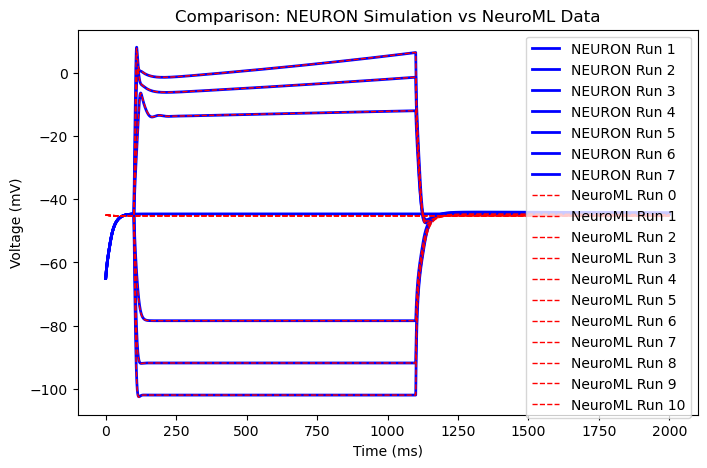

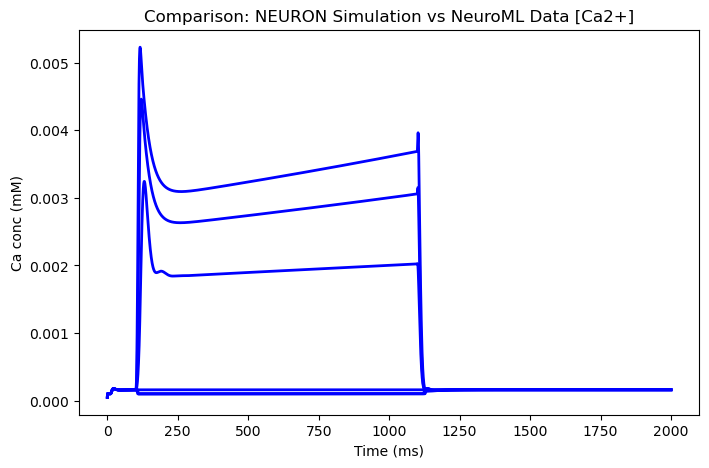

In [6]:
#matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# NEURON simulation data
for i in range(len(v)):
    plt.plot(time1[i], v[i], label=f'NEURON Run {i + 1}', linewidth=2, color='blue')

# NeuroML data
for col in nml_voltages.columns:
    plt.plot(nml_time, df_VD5_NML[col], label=f'NeuroML {col}', linewidth=1, color='red', linestyle='--')


plt.title('Comparison: NEURON Simulation vs NeuroML Data')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')

plt.legend(loc='upper right')

plt.figure(figsize=(8, 5))

# NEURON simulation data
for i in range(len(ca)):
    plt.plot(time1[i], ca[i], label=f'NEURON Run {i + 1}', linewidth=2, color='blue')

# NeuroML data
for col in nml_ca.columns:
    plt.plot(nml_time, dfca_VD5_NML[col], label=f'NeuroML {col}', linewidth=1, color='red', linestyle='--')


plt.title('Comparison: NEURON Simulation vs NeuroML Data [Ca2+]')
plt.xlabel('Time (ms)')
plt.ylabel('Ca conc (mM)')

#plt.legend(loc='upper right')

plt.show()


In [ ]:
# # PLOTLY
# import plotly.graph_objects as go

# # # Create the Plotly figure
# fig = go.Figure()

# # Add NEURON simulation data to the plot
# fig = go.Figure()

# for i in range(len(ca)):
#     fig.add_trace(
#         go.Scatter(
#             x=time1[i], 
#             y=ca[i], 
#             mode='lines', 
#             name=f'NEURON Run {i + 1}', # Label each run
#             line = dict(color = 'blue', width = 2)
#         )
#     )



# # Add NeuroML data to the plot
# for col in nml_voltages.columns:
#     fig.add_trace(
#         go.Scatter(
#             x=nml_time,  # Time from NeuroML data
#             y=dfca_VD5_NML[col],  # Voltage from NeuroML data
#             mode='lines',
#             name=f'NeuroML {col}',  # Label for each trace
#             line=dict(color='red', dash='dash', width=1)
#         )
#     )

# # Update layout for clarity
# fig.update_layout(
#     title='Comparison: NEURON Simulation vs NeuroML Data',
#     xaxis_title='Time (ms)',
#     yaxis_title='Voltage (mV)',
#     template='plotly_white',
#     legend=dict(x=0.99, y=0.99),  # Adjust legend position
#     height=600,  
#     width=800   
# )

# # Show the plot
# fig.show()
